In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors
from matplotlib import font_manager as fm
fpath = "Microsoft Aptos Fonts/Aptos.ttf"
prop = fm.FontProperties(fname=fpath)
#plt.rcParams['font.family'] = 'Aptos'

# Getting the The Number of Employed

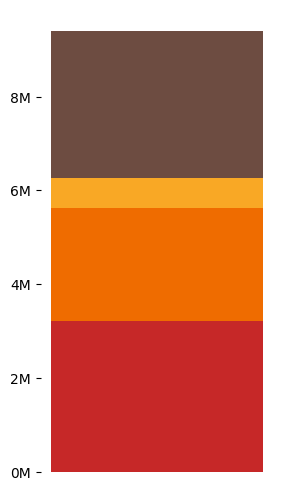

In [4]:
msme_df = pd.read_csv('data/msme.csv')

# Select 2024 row (index 4)
year = msme_df.loc[4, 'Year']
micro = msme_df.loc[4, 'Micro']
small = msme_df.loc[4, 'Small']
medium = msme_df.loc[4, 'Medium']
msme_pct = msme_df.loc[4, 'MSME_to_Total_pct']

# Compute totals
msme_total = micro + small + medium
total_employees = msme_total / (msme_pct / 100)
non_msme = total_employees - msme_total

# Wrap year in list since it's a single bar
year = [year]

plt.figure(figsize=(3, 6))
ax = plt.gca()

# Stack from bottom: Micro → Small → Medium → Non-MSME (on top)
plt.bar(year, [micro], label="Micro", color="#C62828")
plt.bar(year, [small], bottom=[micro], label="Small", color="#EF6C00")
plt.bar(year, [medium], bottom=[micro + small], label="Medium", color="#F9A825")
plt.bar(year, [non_msme], bottom=[micro + small + medium], label="Non-MSME", color="#6D4C41")

# Remove spines for clean look
for spine in ['top','right','bottom','left']:
    ax.spines[spine].set_visible(False)

plt.xticks([])

# Y-axis ticks
yticks = [0, 2000000, 4000000, 6000000, 8000000]
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y//1000000}M" for y in yticks], fontsize=10)


plt.show()

# Getting the Sectors in MSME

In [5]:
employment_df = pd.read_csv('data/sectors.csv', sep=';')
employment_df['Actual'] = np.floor(employment_df['Percentage'] * msme_total / 100)
employment_df

,Sector,Percentage,Actual
0,Wholesale and retail trade,37.9,2369584.0
1,Other services,39.9,2494628.0
2,Manufacturing,12.9,806534.0
3,Transportation and communication,4.5,281349.0
4,"Agriculture, forestry, and fisheries",1.9,118791.0
5,Construction,1.7,106287.0
6,Others,1.3,81278.0


In [6]:
806+534.0

1340.0

In [7]:
2_494_628

2494628

In [8]:
2_375_836.7600000002

2375836.7600000002

In [9]:
236_958_455.0

236958455.0

In [10]:
236_958_455.0

236958455.0

In [11]:
employment_df

,Sector,Percentage,Actual
0,Wholesale and retail trade,37.9,2369584.0
1,Other services,39.9,2494628.0
2,Manufacturing,12.9,806534.0
3,Transportation and communication,4.5,281349.0
4,"Agriculture, forestry, and fisheries",1.9,118791.0
5,Construction,1.7,106287.0
6,Others,1.3,81278.0


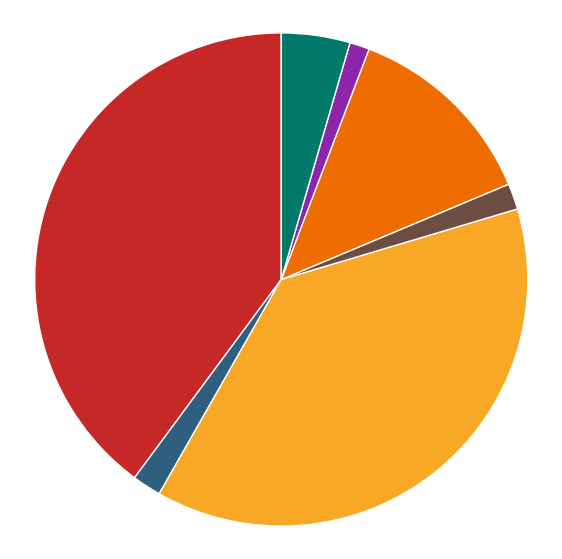

In [12]:
# Your data
employment_df = pd.read_csv('data/sectors.csv', sep=';')
labels = employment_df['Sector']
sizes = employment_df['Percentage']

# Step 1: Sort descending by size
df_sorted = employment_df.sort_values(by='Percentage', ascending=False).reset_index(drop=True)

# Step 2: Split into "big" and "small" slices
mid = (len(df_sorted) + 1) // 2
big = df_sorted.iloc[:mid]
small = df_sorted.iloc[mid:]

# Step 3: Interleave big and small slices
labels_interleaved = []
sizes_interleaved = []

for i in range(mid):
    labels_interleaved.append(big['Sector'].iloc[i])
    sizes_interleaved.append(big['Percentage'].iloc[i])
    if i < len(small):
        labels_interleaved.append(small['Sector'].iloc[i])
        sizes_interleaved.append(small['Percentage'].iloc[i])

# Step 4: Plot pie

colors = [
    "#C62828",  # deep red
    "#2E5F7F",  # muted blue-gray
    "#F9A825",  # golden yellow
    "#6D4C41",  # brown
    "#EF6C00",  # orange
    "#8E24AA",  # muted purple
    "#00796B",  # teal-green
    "#FF7043",  # soft coral
    "#FFD54F",  # soft yellow
    "#5D4037"   # dark brown
]


plt.figure(figsize=(7,7), facecolor='none')
plt.pie(
    sizes_interleaved,
    #labels=labels_interleaved,
    #autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(sizes_interleaved)],
    wedgeprops={'edgecolor':'white'}
)
plt.axis('equal')
#plt.title("Employment Distribution by Sector (2024)")
plt.show()

In [13]:
len(colors)

10

In [14]:
sector_df

NameError: name 'sector_df' is not defined

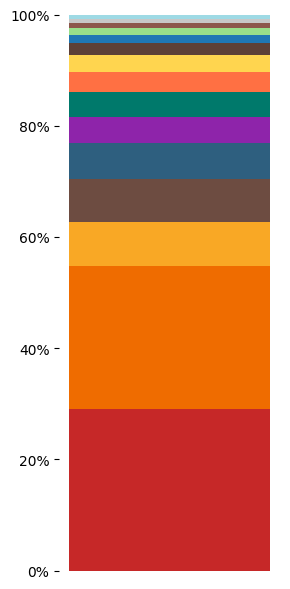

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
aspbi_df = pd.read_csv('data/aggregated_aspbi.csv')

# Filter for Philippines and select relevant columns
ph_df = aspbi_df[aspbi_df['Region Description'] == 'Philippines']
sector_df = ph_df[['Job Sector', 'Total']].sort_values(by='Total', ascending=False)

# Compute percentage
sector_df['Percentage'] = (sector_df['Total'] / sector_df['Total'].sum()) * 100
sector_df['Percentage'] = sector_df['Percentage'].round(2)

# Colors for the sectors (biggest ones first)
# Use your first 10 colors, then generate more for the rest
n_sectors = len(sector_df)

base_colors = [
    "#C62828", "#EF6C00", "#F9A825", "#6D4C41",
    "#2E5F7F", "#8E24AA", "#00796B", "#FF7043",
    "#FFD54F", "#5D4037"
]

if n_sectors > len(base_colors):
    # Generate extra colors using a colormap
    extra_colors = plt.cm.tab20(np.linspace(0, 1, n_sectors - len(base_colors)))
    colors = base_colors + [mcolors.to_hex(c) for c in extra_colors]
else:
    colors = base_colors[:n_sectors]

# Make sure we don't run out of colors
colors = colors[:len(sector_df)]

# Plot stacked bar
fig, ax = plt.subplots(figsize=(3, 6))

bottom = 0
for i, (sector, pct) in enumerate(zip(sector_df['Job Sector'], sector_df['Percentage'])):
    ax.bar(
        'Philippines', 
        pct, 
        bottom=bottom, 
        color=colors[i], 
        label=sector
    )
    bottom += pct

#Add labels
#ax.set_ylabel('Percentage of Total Employment')
#ax.set_title('Employment Distribution by Job Sector in the Philippines')
#ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove spines for clean look
for spine in ['top','right','bottom','left']:
    ax.spines[spine].set_visible(False)


plt.xticks([])

# Format y-axis as percentages
ax.set_ylim(0, 100)  # Ensure y-axis goes from 0 to 100%
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))


plt.gca().spines
plt.tight_layout()
plt.show()

In [16]:
sector_df

,Job Sector,Total,Percentage
90,Administrative and Support Service Activities ...,1364700.0,29.02
54,Wholesale and Retail Trade; Repair of Motor Ve...,1211357.0,25.76
109,Financial and Insurance Activities,373866.0,7.95
184,Accommodation and Food Service Activities,363970.0,7.74
72,Education,298370.0,6.34
36,Transportation and Storage,221493.0,4.71
165,Human Health and Social Work Activities,215729.0,4.59
128,Information and Communication,169331.0,3.60
220,"Professional, Scientific and Technical Activities",139732.0,2.97
147,Real Estate Activities,104095.0,2.21
